5 B

Pima Dataset Shape: (768, 9)
UCI Dataset Shape: (768, 9)

PIMA DIABETES DATASET
Accuracy : 0.7662
Precision: 0.6939
Recall   : 0.6182
F1 Score : 0.6538

UCI DIABETES DATASET
Accuracy : 0.7662
Precision: 0.6939
Recall   : 0.6182
F1 Score : 0.6538


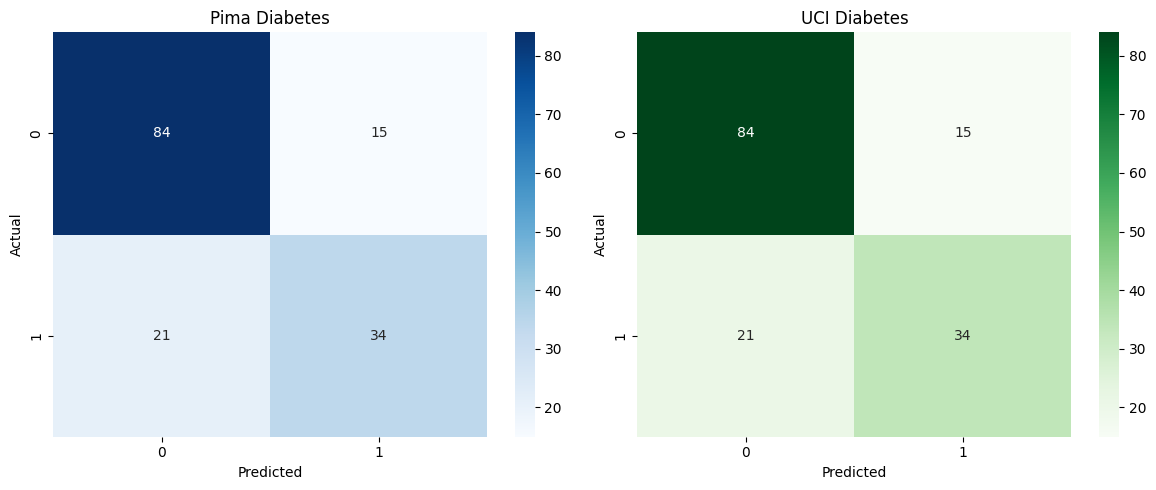

In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================
# LOAD DATASETS FROM ONLINE
# ============================================

# Pima Diabetes Dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

pima_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

pima_diabetes = pd.read_csv(
    pima_url,
    names=pima_columns
)

# Second Diabetes Dataset
uci_url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"

uci_diabetes = pd.read_csv(uci_url)

# ============================================
# DISPLAY DATASET INFO
# ============================================

print("Pima Dataset Shape:", pima_diabetes.shape)
print("UCI Dataset Shape:", uci_diabetes.shape)

# ============================================
# SELECT FEATURES AND TARGET
# ============================================

features = ["Glucose", "BloodPressure", "BMI"]
target = "Outcome"

X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

# ============================================
# SPLIT DATA
# ============================================

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima,
    y_pima,
    test_size=0.2,
    random_state=42
)

X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci,
    y_uci,
    test_size=0.2,
    random_state=42
)

# ============================================
# TRAIN MODELS
# ============================================

model_pima = LogisticRegression(max_iter=1000)

model_uci = LogisticRegression(max_iter=1000)

model_pima.fit(X_train_pima, y_train_pima)

model_uci.fit(X_train_uci, y_train_uci)

# ============================================
# PREDICTIONS
# ============================================

y_pred_pima = model_pima.predict(X_test_pima)

y_pred_uci = model_uci.predict(X_test_uci)

# ============================================
# EVALUATION - PIMA
# ============================================

accuracy_pima = accuracy_score(y_test_pima, y_pred_pima)
precision_pima = precision_score(y_test_pima, y_pred_pima)
recall_pima = recall_score(y_test_pima, y_pred_pima)
f1_pima = f1_score(y_test_pima, y_pred_pima)

# ============================================
# EVALUATION - UCI
# ============================================

accuracy_uci = accuracy_score(y_test_uci, y_pred_uci)
precision_uci = precision_score(y_test_uci, y_pred_uci)
recall_uci = recall_score(y_test_uci, y_pred_uci)
f1_uci = f1_score(y_test_uci, y_pred_uci)

# ============================================
# DISPLAY RESULTS
# ============================================

print("\n===================================")
print("PIMA DIABETES DATASET")
print("===================================")

print(f"Accuracy : {accuracy_pima:.4f}")
print(f"Precision: {precision_pima:.4f}")
print(f"Recall   : {recall_pima:.4f}")
print(f"F1 Score : {f1_pima:.4f}")

print("\n===================================")
print("UCI DIABETES DATASET")
print("===================================")

print(f"Accuracy : {accuracy_uci:.4f}")
print(f"Precision: {precision_uci:.4f}")
print(f"Recall   : {recall_uci:.4f}")
print(f"F1 Score : {f1_uci:.4f}")

# ============================================
# CONFUSION MATRICES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pima
sns.heatmap(
    confusion_matrix(y_test_pima, y_pred_pima),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("Pima Diabetes")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# UCI
sns.heatmap(
    confusion_matrix(y_test_uci, y_pred_uci),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)

axes[1].set_title("UCI Diabetes")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()